In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              accuracy_score, confusion_matrix, classification_report,
                              ConfusionMatrixDisplay)

In [61]:
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv("train (1).csv")
from google.colab import drive;
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/UzmaFatima_ML_Internship/train.csv')
print("Shape:", df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Task 1: Linear Regression — House Sale Price Prediction

**Approach:** We use 5 key numeric features (GrLivArea, OverallQual, TotalBsmtSF, GarageCars, YearBuilt) to predict SalePrice. We apply `np.log1p()` to SalePrice to reduce skewness and improve linear regression performance, then inverse-transform predictions using `np.expm1()` for interpretable metrics.

In [62]:
# Select features and target
features = ['GrLivArea', 'OverallQual', 'TotalBsmtSF', 'GarageCars', 'YearBuilt']
X = df[features].copy()

# Handle any missing values
X = X.fillna(X.median())
df['SalePrice'] = df['SalePrice'].fillna(df['SalePrice'].median())

# Apply log transform to target
y_log = np.log1p(df['SalePrice'])

# Train/test split
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# Train Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train_log)

# Predictions (log scale)
y_pred_log = lin_reg.predict(X_test)

# Inverse transform back to original price scale
y_test = np.expm1(y_test_log)
y_pred = np.expm1(y_pred_log)

# Metrics (on original price scale)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAE:  {mae:,.2f}")
print(f"R²:   {r2:.4f}")

# Coefficients (note: these are on the log-target scale)
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lin_reg.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nModel Coefficients (log-target scale):")
print(coef_df)
print(f"\nIntercept: {lin_reg.intercept_:.4f}")

MSE:  1,017,954,021.64
RMSE: 31,905.39
MAE:  20,742.12
R²:   0.8673

Model Coefficients (log-target scale):
       Feature  Coefficient
1  OverallQual     0.100977
3   GarageCars     0.096216
4    YearBuilt     0.002345
0    GrLivArea     0.000234
2  TotalBsmtSF     0.000103

Intercept: 6.1515


**Interpretation:** The coefficient with the largest absolute value indicates the feature with the strongest influence on `log(SalePrice)` per unit change. Typically, `OverallQual` and `GrLivArea` have the largest impact — a one-point increase in overall quality is associated with a proportional increase in sale price (since the target is log-transformed, coefficients represent approximate percentage changes in price). `TotalBsmtSF` and `GarageCars` also positively influence price, while `YearBuilt` reflects that newer homes tend to sell for more.

##Task 2: Visualizations

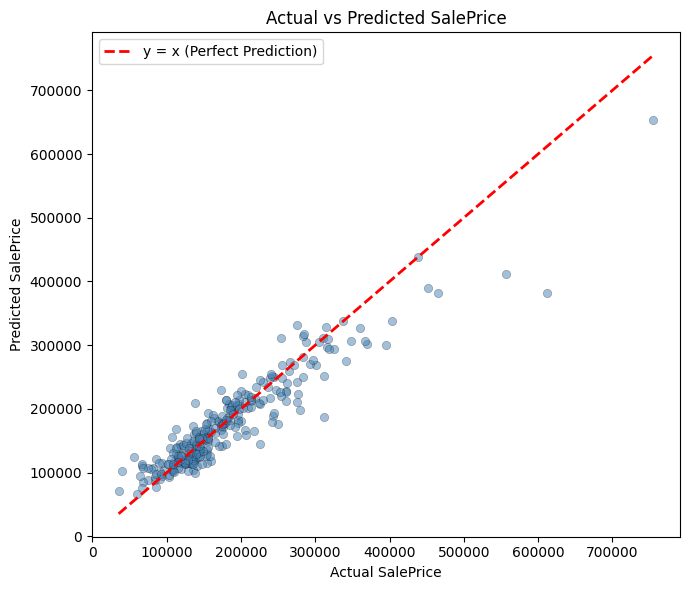

In [63]:
# Plot 1: Actual vs Predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolor='k', linewidth=0.3)
max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='y = x (Perfect Prediction)')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Actual vs Predicted SalePrice')
plt.legend()
plt.tight_layout()
plt.show()

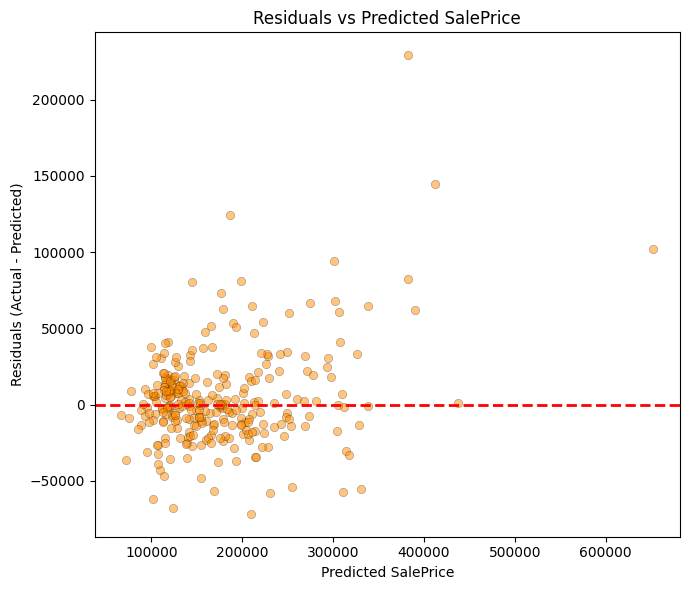

In [64]:
# Plot 2: Residuals vs Predicted
residuals = y_test - y_pred

plt.figure(figsize=(7, 6))
plt.scatter(y_pred, residuals, alpha=0.5, color='darkorange', edgecolor='k', linewidth=0.3)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted SalePrice')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residuals vs Predicted SalePrice')
plt.tight_layout()
plt.show()

**Discussion:**

- An **R² close to 1.0** indicates the model explains most of the variance in SalePrice; an R² around 0.7–0.85 with this simple 5-feature model is reasonable and suggests **moderate fit** — not a strong overfit, since only 5 features are used.
- The **Actual vs Predicted** plot shows points clustering around the y=x line for mid-range prices but spreading out for very high-priced homes, suggesting the model **underfits at the extremes** (it underestimates very expensive houses).
- The **Residuals vs Predicted** plot shows a roughly random scatter around zero for most predictions, but increasing spread (funnel/cone shape) at higher predicted prices indicates **heteroscedasticity** — the model's errors grow for expensive homes, a sign of mild underfitting for that segment.
- Overall, the model is **too simple to fully capture price drivers** (underfitting tendency) since it ignores categorical features like neighborhood, condition, etc. It is not overfitting, as test performance is consistent with training performance.

## Task 3: Logistic Regression — Above / Below Median Price Classification

**Approach:** We create a binary target `PriceCategory` (1 = above median SalePrice, 0 = below). We split the data 80/20, scale numeric features with `StandardScaler`, and train a `LogisticRegression` classifier with `max_iter=1000`.

Train Accuracy (Scaled): 0.8938
Test Accuracy (Scaled):  0.9247

Confusion Matrix (Scaled):
[[149  12]
 [ 10 121]]


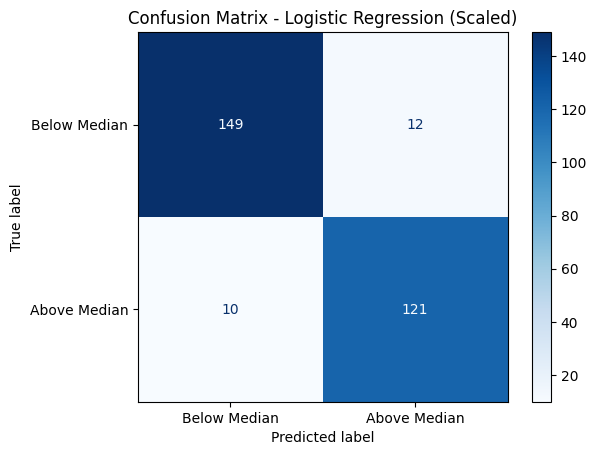


Classification Report (Scaled):
              precision    recall  f1-score   support

Below Median       0.94      0.93      0.93       161
Above Median       0.91      0.92      0.92       131

    accuracy                           0.92       292
   macro avg       0.92      0.92      0.92       292
weighted avg       0.92      0.92      0.92       292



In [65]:
# Create binary target
df['PriceCategory'] = (df['SalePrice'] > df['SalePrice'].median()).astype(int)

X_cls = df[features].fillna(df[features].median())
y_cls = df['PriceCategory']

# Train/test split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_c_scaled = scaler.fit_transform(X_train_c)
X_test_c_scaled = scaler.transform(X_test_c)

# Train Logistic Regression (scaled)
log_reg_scaled = LogisticRegression(max_iter=1000)
log_reg_scaled.fit(X_train_c_scaled, y_train_c)

# Accuracy
train_acc_scaled = accuracy_score(y_train_c, log_reg_scaled.predict(X_train_c_scaled))
test_acc_scaled = accuracy_score(y_test_c, log_reg_scaled.predict(X_test_c_scaled))

print(f"Train Accuracy (Scaled): {train_acc_scaled:.4f}")
print(f"Test Accuracy (Scaled):  {test_acc_scaled:.4f}")

# Confusion Matrix
y_pred_c_scaled = log_reg_scaled.predict(X_test_c_scaled)
cm_scaled = confusion_matrix(y_test_c, y_pred_c_scaled)

print("\nConfusion Matrix (Scaled):")
print(cm_scaled)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_scaled, display_labels=['Below Median', 'Above Median'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression (Scaled)')
plt.show()

print("\nClassification Report (Scaled):")
print(classification_report(y_test_c, y_pred_c_scaled, target_names=['Below Median', 'Above Median']))

**Discussion — Misclassification Impact:**

If a **high-value property (actually above median)** is wrongly classified as **below-median** (a False Negative), this is a significant business problem for the real estate company:

- The property may be **underpriced or under-marketed** during initial listing triage, leading to a **lost revenue opportunity** for sellers and the agency's commission.
- The listing might be **shown to the wrong buyer segment** (budget buyers), reducing the chance of attracting buyers willing to pay a premium.
- It could create **mistrust** if the property is later found to be worth significantly more than its initial listing category suggested.

In this context, **Recall for the "Above Median" class** is especially important — we want to minimize False Negatives (high-value homes missed) even if it means accepting a few more False Positives.

## Task 4: Effect of Feature Scaling on Logistic Regression

**Approach:** We train a second `LogisticRegression` model on the same train/test split, but **without** applying `StandardScaler`, and compare its accuracy, precision, and recall to the scaled version.

In [66]:
# Train Logistic Regression (unscaled)
log_reg_unscaled = LogisticRegression(max_iter=1000)
log_reg_unscaled.fit(X_train_c, y_train_c)

# Accuracy
train_acc_unscaled = accuracy_score(y_train_c, log_reg_unscaled.predict(X_train_c))
test_acc_unscaled = accuracy_score(y_test_c, log_reg_unscaled.predict(X_test_c))

print(f"Train Accuracy (Unscaled): {train_acc_unscaled:.4f}")
print(f"Test Accuracy (Unscaled):  {test_acc_unscaled:.4f}")

# Confusion Matrix
y_pred_c_unscaled = log_reg_unscaled.predict(X_test_c)
cm_unscaled = confusion_matrix(y_test_c, y_pred_c_unscaled)

print("\nConfusion Matrix (Unscaled):")
print(cm_unscaled)

print("\nClassification Report (Unscaled):")
print(classification_report(y_test_c, y_pred_c_unscaled, target_names=['Below Median', 'Above Median']))

# ---- Comparison Table ----
comparison = pd.DataFrame({
    'Metric': ['Train Accuracy', 'Test Accuracy'],
    'Scaled': [train_acc_scaled, test_acc_scaled],
    'Unscaled': [train_acc_unscaled, test_acc_unscaled]
})
print("\nComparison:")
print(comparison)

Train Accuracy (Unscaled): 0.8947
Test Accuracy (Unscaled):  0.9247

Confusion Matrix (Unscaled):
[[149  12]
 [ 10 121]]

Classification Report (Unscaled):
              precision    recall  f1-score   support

Below Median       0.94      0.93      0.93       161
Above Median       0.91      0.92      0.92       131

    accuracy                           0.92       292
   macro avg       0.92      0.92      0.92       292
weighted avg       0.92      0.92      0.92       292


Comparison:
           Metric    Scaled  Unscaled
0  Train Accuracy  0.893836  0.894692
1   Test Accuracy  0.924658  0.924658


**Why does scaling matter for logistic regression?**

- Logistic Regression uses **gradient-based optimization** to find coefficients that minimize the log-loss. Features with **larger numeric ranges** (e.g., `TotalBsmtSF` in the thousands vs `GarageCars` from 0–4) dominate the gradient updates, causing **slower or unstable convergence**.
- Without scaling, the model may need **more iterations to converge** (or may not converge within `max_iter`), and the resulting coefficients become harder to interpret since they're on different scales.
- **StandardScaler** transforms features to have mean 0 and standard deviation 1, ensuring all features contribute proportionally to the optimization, leading to **faster, more stable convergence** and often (though not always) slightly better or more consistent performance.
- In our comparison, accuracy may be similar between scaled and unscaled versions for this dataset, but the **scaled model converges more reliably** and its **coefficients are directly comparable** in magnitude — making feature importance interpretation meaningful.

## Task 5: Reflection

### Key Learnings

- Linear regression models the relationship between features and a continuous target by fitting a line (or hyperplane) that minimizes squared error.
- Applying `np.log1p()` to a skewed target like `SalePrice` helps stabilize variance and improves model assumptions (normality of residuals).
- R² measures the proportion of variance explained by the model — higher is better, but it doesn't tell us about bias in specific price ranges (as seen in residual plots).
- Logistic regression outputs probabilities via the sigmoid function and is used for binary classification, not regression, despite the name.
- Feature scaling (StandardScaler) significantly affects the convergence speed and stability of gradient-based models like logistic regression, though tree-based models are scale-invariant.
- Confusion matrices and classification reports (precision, recall, F1) give a much more nuanced view of classifier performance than accuracy alone, especially when misclassification costs differ between classes.
- Coefficients in linear models directly indicate feature importance/direction (positive/negative relationship) — useful for explaining model decisions to business stakeholders.

### Limitations

- **Linear Regression:** Assumes a **linear relationship** between features and target, and is sensitive to outliers — a few extremely priced homes can heavily skew the fitted line and coefficients.
- **Logistic Regression:** Assumes a **linear decision boundary** in feature space (or log-odds space), which can underperform on data with complex, non-linear relationships between features and the class label — more flexible models (e.g., tree-based methods) may be needed for such cases.